DATA LABEL ERROR FIX:

In [ ]:
!wget -O /content/drive/MyDrive/SignLanguageProject/WLASL_v0.3.json https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json

import os
if os.path.exists('/content/drive/MyDrive/SignLanguageProject/WLASL_v0.3.json'):
    print("✅ WLASL_v0.3.json successfully downloaded to your project folder!")

--2026-07-31 16:12:34--  https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11932637 (11M) [text/plain]
Saving to: ‘/content/drive/MyDrive/SignLanguageProject/WLASL_v0.3.json’

/content/drive/MyDr 100%[===================>]  11.38M  57.5MB/s    in 0.2s    

2026-07-31 16:12:35 (57.5 MB/s) - ‘/content/drive/MyDrive/SignLanguageProject/WLASL_v0.3.json’ saved [11932637/11932637]

✅ WLASL_v0.3.json successfully downloaded to your project folder!


In [ ]:
import glob
import json
import os
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset

# --- 1. CONFIGURATION ---
DATA_DIR = '/content/drive/MyDrive/SignLanguageProject/augmented_landmarks'
MAPPING_FILE = (
    '/content/drive/MyDrive/SignLanguageProject/class_mapping_100.json'
)

# Search for WLASL_v0.3.json in Google Drive
WLASL_JSON_PATH = '/content/drive/MyDrive/SignLanguageProject/WLASL_v0.3.json'
if not os.path.exists(WLASL_JSON_PATH):
  # Try alternative common location
  WLASL_JSON_PATH = '/content/drive/MyDrive/WLASL_v0.3.json'

MAX_SEQ_LENGTH = 40
BATCH_SIZE = 32
RANDOM_SEED = 42

# --- 2. LOAD CLASS MAPPING ---
with open(MAPPING_FILE, 'r') as f:
  class_mapping = json.load(f)  # e.g. {"book": 0, "drink": 1, ...}

# --- 3. LOAD WLASL JSON TO BUILD VIDEO_ID -> GLOSS MAP ---
video_to_class = {}

if os.path.exists(WLASL_JSON_PATH):
  print(f'📖 Loading WLASL metadata from: {WLASL_JSON_PATH}')
  with open(WLASL_JSON_PATH, 'r') as f:
    wlasl_data = json.load(f)

  for entry in wlasl_data:
    gloss = entry['gloss']
    if gloss in class_mapping:
      target_label = class_mapping[gloss]
      for inst in entry['instances']:
        vid_id = str(inst['video_id'])
        video_to_class[vid_id] = target_label

  print(
      f'✅ Successfully mapped {len(video_to_class)} video IDs to class'
      ' labels.'
  )

else:
  raise FileNotFoundError(
      f'Could not find `WLASL_v0.3.json` at {WLASL_JSON_PATH}. Please check its'
      ' path on Google Drive!'
  )

# --- 4. GET ALL PROCESSED FILES AND MATCH REAL LABELS ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.npy'))
if len(all_files) == 0:
  raise FileNotFoundError(f'No .npy files found in {DATA_DIR}!')

matched_files = []
matched_labels = []
base_to_files = {}

for file_path in all_files:
  fname = os.path.basename(file_path).replace('.npy', '')
  base_id = fname.replace('_aug', '')

  if base_id in video_to_class:
    label = video_to_class[base_id]
    if base_id not in base_to_files:
      base_to_files[base_id] = {'files': [], 'label': label}
    base_to_files[base_id]['files'].append(file_path)

unique_base_ids = list(base_to_files.keys())
unique_base_labels = [base_to_files[b]['label'] for b in unique_base_ids]

print(
    f'🎯 Matched {len(unique_base_ids)} unique video bases across'
    f' {sum(len(v["files"]) for v in base_to_files.values())} files!'
)

# --- 5. STRATIFIED 80/10/10 SPLIT BY BASE ID ---
train_bids, temp_bids, train_lbls, temp_lbls = train_test_split(
    unique_base_ids,
    unique_base_labels,
    test_size=0.2,
    stratify=unique_base_labels,
    random_state=RANDOM_SEED,
)

val_bids, test_bids = train_test_split(
    temp_bids,
    test_size=0.5,
    random_state=RANDOM_SEED,  # Unstratified second split avoids sparse class errors
)


def collect_split_data(bids):
  files, targets = [], []
  for b in bids:
    files.extend(base_to_files[b]['files'])
    targets.extend([base_to_files[b]['label']] * len(base_to_files[b]['files']))
  return files, targets


train_files, train_targets = collect_split_data(train_bids)
val_files, val_targets = collect_split_data(val_bids)
test_files, test_targets = collect_split_data(test_bids)


# --- 6. DATASET CLASS WITH NORMALIZATION ---
class SignLanguageDataset(Dataset):

  def __init__(self, file_paths, targets, max_frames=40):
    self.file_paths = file_paths
    self.targets = targets
    self.max_frames = max_frames

  def __len__(self):
    return len(self.file_paths)

  def __getitem__(self, idx):
    sequence = np.load(self.file_paths[idx]).astype(np.float32)

    # Z-score Normalization per video sequence
    std = np.std(sequence)
    if std > 1e-6:
      sequence = (sequence - np.mean(sequence)) / std

    num_frames, feat_dim = sequence.shape

    # Temporal Cropping / Padding
    if num_frames < self.max_frames:
      padding = np.zeros(
          (self.max_frames - num_frames, feat_dim), dtype=np.float32
      )
      sequence = np.vstack((sequence, padding))
    elif num_frames > self.max_frames:
      start = (num_frames - self.max_frames) // 2
      sequence = sequence[start : start + self.max_frames, :]

    label = self.targets[idx]
    return torch.tensor(sequence, dtype=torch.float32), torch.tensor(
        label, dtype=torch.long
    )


# --- 7. DATALOADERS ---
train_loader = DataLoader(
    SignLanguageDataset(
        train_files, train_targets, max_frames=MAX_SEQ_LENGTH
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    SignLanguageDataset(
        val_files, val_targets, max_frames=MAX_SEQ_LENGTH
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    SignLanguageDataset(
        test_files, test_targets, max_frames=MAX_SEQ_LENGTH
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('\n' + '=' * 50)
print('🚀 PERFECT DATALOADERS READY WITH REAL WLASL LABELS!')
print('=' * 50)
print(
    f'Training Split:   {len(train_files)} sequences ({len(train_loader)}'
    ' batches)'
)
print(
    f'Validation Split: {len(val_files)} sequences ({len(val_loader)} batches)'
)
print(
    f'Test Split:       {len(test_files)} sequences ({len(test_loader)}'
    ' batches)'
)
print('=' * 50)

📖 Loading WLASL metadata from: /content/drive/MyDrive/SignLanguageProject/WLASL_v0.3.json
✅ Successfully mapped 2038 video IDs to class labels.
🎯 Matched 953 unique video bases across 1906 files!

🚀 PERFECT DATALOADERS READY WITH REAL WLASL LABELS!
Training Split:   1524 sequences (48 batches)
Validation Split: 190 sequences (6 batches)
Test Split:       192 sequences (6 batches)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- SYSTEM & FILE I/O ---
import os
import glob
import json
import warnings

# --- DATA MANIPULATION ---
import numpy as np
import pandas as pd

# --- MACHINE LEARNING & EVALUATION ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- PYTORCH DEEP LEARNING ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# --- VISUALIZATION & PROGRESS ---
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- ENVIRONMENT CONFIGURATION ---
warnings.filterwarnings('ignore') # Suppress messy warnings

# Set random seeds for reproducibility (ensures you get the same results if you rerun)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

# Detect hardware (GPU vs CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ All libraries imported successfully!")
print(f"🔥 Active Compute Device: {device.type.upper()}")

✅ All libraries imported successfully!
🔥 Active Compute Device: CUDA


# PyTorch Dataset and DataLoader

In [ ]:
import glob
import json
import os
import random
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset

# --- 1. CONFIGURATION ---
DATA_DIR = '/content/drive/MyDrive/SignLanguageProject/augmented_landmarks'
MAPPING_FILE = (
    '/content/drive/MyDrive/SignLanguageProject/class_mapping_100.json'
)
WLASL_JSON_PATH = '/content/drive/MyDrive/SignLanguageProject/WLASL_v0.3.json'

MAX_SEQ_LENGTH = 40
BATCH_SIZE = 32
RANDOM_SEED = 42

# --- 2. LOAD METADATA ---
with open(MAPPING_FILE, 'r') as f:
  class_mapping = json.load(f)

with open(WLASL_JSON_PATH, 'r') as f:
  wlasl_data = json.load(f)

video_to_class = {}
for entry in wlasl_data:
  gloss = entry['gloss']
  if gloss in class_mapping:
    target_label = class_mapping[gloss]
    for inst in entry['instances']:
      vid_id = str(inst['video_id'])
      video_to_class[vid_id] = target_label

# --- 3. FILE MATCHING & SPLITTING ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.npy'))
base_to_files = {}

for file_path in all_files:
  fname = os.path.basename(file_path).replace('.npy', '')
  base_id = fname.replace('_aug', '')

  if base_id in video_to_class:
    label = video_to_class[base_id]
    if base_id not in base_to_files:
      base_to_files[base_id] = {'files': [], 'label': label}
    base_to_files[base_id]['files'].append(file_path)

unique_base_ids = list(base_to_files.keys())
unique_base_labels = [base_to_files[b]['label'] for b in unique_base_ids]

train_bids, temp_bids, train_lbls, temp_lbls = train_test_split(
    unique_base_ids,
    unique_base_labels,
    test_size=0.2,
    stratify=unique_base_labels,
    random_state=RANDOM_SEED,
)

val_bids, test_bids = train_test_split(
    temp_bids, test_size=0.5, random_state=RANDOM_SEED
)


def collect_split_data(bids):
  files, targets = [], []
  for b in bids:
    files.extend(base_to_files[b]['files'])
    targets.extend([base_to_files[b]['label']] * len(base_to_files[b]['files']))
  return files, targets


train_files, train_targets = collect_split_data(train_bids)
val_files, val_targets = collect_split_data(val_bids)
test_files, test_targets = collect_split_data(test_bids)


# --- 4. ADVANCED FEATURE ENGINEERED & AUGMENTED DATASET ---
class AdvancedSignDataset(Dataset):

  def __init__(self, file_paths, targets, max_frames=40, augment=False):
    self.max_frames = max_frames
    self.targets = targets
    self.augment = augment
    self.raw_sequences = []

    print(
        f'⚡ Preloading & Feature Engineering {len(file_paths)} sequences'
        f' (Augment={augment})...'
    )
    for fpath in file_paths:
      seq = np.load(fpath).astype(np.float32)

      # Min-Max Normalization per sequence
      min_val, max_val = np.min(seq), np.max(seq)
      if max_val - min_val > 1e-6:
        seq = (seq - min_val) / (max_val - min_val)

      # Pad / Crop to max_frames
      num_frames, feat_dim = seq.shape
      if num_frames < self.max_frames:
        padding = np.zeros(
            (self.max_frames - num_frames, feat_dim), dtype=np.float32
        )
        seq = np.vstack((seq, padding))
      elif num_frames > self.max_frames:
        start = (num_frames - self.max_frames) // 2
        seq = seq[start : start + self.max_frames, :]

      # Velocity Features (Frame-to-Frame derivative)
      velocity = np.zeros_like(seq)
      velocity[1:] = seq[1:] - seq[:-1]

      # Concatenate Raw Coordinates + Velocity (Feature Dim: 258 -> 516)
      combined_features = np.concatenate([seq, velocity], axis=-1)
      self.raw_sequences.append(combined_features)

    self.raw_sequences = np.array(self.raw_sequences, dtype=np.float32)
    self.targets = np.array(self.targets, dtype=np.int64)
    print('✅ Preloading & Velocity Extraction Complete!')

  def __len__(self):
    return len(self.targets)

  def __getitem__(self, idx):
    seq = self.raw_sequences[idx].copy()  # (40, 516)

    # Dynamic Online Data Augmentation (Train Mode Only)
    if self.augment:
      # 1. Random Coordinate Jittering (Noise)
      if random.random() < 0.5:
        noise = np.random.normal(0, 0.005, size=seq.shape).astype(np.float32)
        seq += noise

      # 2. Random Spatial Scaling (95% to 105%)
      if random.random() < 0.5:
        scale_factor = random.uniform(0.95, 1.05)
        seq[:, :258] *= scale_factor  # Scale position channels

    return torch.tensor(seq, dtype=torch.float32), torch.tensor(
        self.targets[idx], dtype=torch.long
    )


# --- 5. INITIALIZE DATALOADERS ---
train_loader = DataLoader(
    AdvancedSignDataset(
        train_files, train_targets, max_frames=MAX_SEQ_LENGTH, augment=True
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    AdvancedSignDataset(
        val_files, val_targets, max_frames=MAX_SEQ_LENGTH, augment=False
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    AdvancedSignDataset(
        test_files, test_targets, max_frames=MAX_SEQ_LENGTH, augment=False
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('\n' + '=' * 60)
print('🚀 ADVANCED DATALOADERS READY (516 FEATURES: COORDS + VELOCITY)')
print('=' * 60)

⚡ Preloading & Feature Engineering 1524 sequences (Augment=True)...
✅ Preloading & Velocity Extraction Complete!
⚡ Preloading & Feature Engineering 190 sequences (Augment=False)...
✅ Preloading & Velocity Extraction Complete!
⚡ Preloading & Feature Engineering 192 sequences (Augment=False)...
✅ Preloading & Velocity Extraction Complete!

🚀 ADVANCED DATALOADERS READY (516 FEATURES: COORDS + VELOCITY)


In [ ]:
# import glob
# import json
# import os
# import numpy as np
# from sklearn.model_selection import train_test_split
# import torch
# from torch.utils.data import DataLoader, Dataset

# # --- 1. CONFIGURATION ---
# DATA_DIR = '/content/drive/MyDrive/SignLanguageProject/augmented_landmarks'
# MAPPING_FILE = (
#     '/content/drive/MyDrive/SignLanguageProject/class_mapping_100.json'
# )

# MAX_SEQ_LENGTH = 40
# BATCH_SIZE = 32
# RANDOM_SEED = 42

# # --- 2. LOAD CLASS MAPPING ---
# with open(MAPPING_FILE, 'r') as f:
#   class_mapping = json.load(f)

# # Ensure a deterministic order of classes [0..99]
# sorted_classes = sorted(list(class_mapping.keys()))
# gloss_to_id = {gloss: i for i, gloss in enumerate(sorted_classes)}

# # --- 3. GET ALL PROCESSED FILES ---
# all_files = glob.glob(os.path.join(DATA_DIR, '*.npy'))

# if len(all_files) == 0:
#   raise FileNotFoundError(
#       f'No .npy files found in {DATA_DIR}. Check your Drive mount or path!'
#   )

# # --- 4. MAP BASE VIDEO IDs TO FIXED DETERMINISTIC LABELS ---
# base_id_to_label = {}
# valid_base_ids = set()

# for file_path in all_files:
#   filename = os.path.basename(file_path).replace('.npy', '')
#   base_id = filename.replace('_aug', '')
#   valid_base_ids.add(base_id)

#   if base_id not in base_id_to_label:
#     # Deterministic integer conversion based on numerical video ID
#     base_id_to_label[base_id] = int(abs(int(base_id)) % len(sorted_classes))

# valid_base_ids = list(valid_base_ids)
# base_labels = [base_id_to_label[b_id] for b_id in valid_base_ids]

# # --- 5. STRATIFIED 80/10/10 SPLIT ---
# train_ids, temp_ids, train_lbls, temp_lbls = train_test_split(
#     valid_base_ids,
#     base_labels,
#     test_size=0.2,
#     stratify=base_labels,
#     random_state=RANDOM_SEED,
# )

# val_ids, test_ids = train_test_split(
#     temp_ids,
#     test_size=0.5,
#     stratify=temp_lbls,
#     random_state=RANDOM_SEED,
# )


# def get_files_for_split(split_ids):
#   split_set = set(split_ids)
#   return [
#       f
#       for f in all_files
#       if os.path.basename(f).replace('.npy', '').replace('_aug', '')
#       in split_set
#   ]


# train_files = get_files_for_split(train_ids)
# val_files = get_files_for_split(val_ids)
# test_files = get_files_for_split(test_ids)


# # --- 6. DATASET CLASS WITH NORMALIZATION ---
# class SignLanguageDataset(Dataset):

#   def __init__(self, file_paths, base_id_to_label, max_frames=40):
#     self.file_paths = file_paths
#     self.max_frames = max_frames
#     self.base_id_to_label = base_id_to_label

#   def __len__(self):
#     return len(self.file_paths)

#   def __getitem__(self, idx):
#     file_path = self.file_paths[idx]
#     sequence = np.load(file_path).astype(np.float32)

#     # 1. Feature Normalization (Z-score scaling per sequence)
#     std = np.std(sequence)
#     if std > 1e-6:
#       sequence = (sequence - np.mean(sequence)) / std

#     num_frames, feat_dim = sequence.shape

#     # 2. Center-Cropping / Padding
#     if num_frames < self.max_frames:
#       padding = np.zeros(
#           (self.max_frames - num_frames, feat_dim), dtype=np.float32
#       )
#       sequence = np.vstack((sequence, padding))
#     elif num_frames > self.max_frames:
#       excess_frames = num_frames - self.max_frames
#       start_idx = excess_frames // 2
#       sequence = sequence[start_idx : start_idx + self.max_frames, :]

#     # 3. Retrieve Deterministic Fixed Label
#     filename = os.path.basename(file_path).replace('.npy', '')
#     base_id = filename.replace('_aug', '')
#     label_idx = self.base_id_to_label[base_id]

#     return torch.tensor(sequence, dtype=torch.float32), torch.tensor(
#         label_idx, dtype=torch.long
#     )


# # --- 7. INITIALIZE DATALOADERS ---
# train_loader = DataLoader(
#     SignLanguageDataset(train_files, base_id_to_label, max_frames=MAX_SEQ_LENGTH),
#     batch_size=BATCH_SIZE,
#     shuffle=True,
# )
# val_loader = DataLoader(
#     SignLanguageDataset(val_files, base_id_to_label, max_frames=MAX_SEQ_LENGTH),
#     batch_size=BATCH_SIZE,
#     shuffle=False,
# )
# test_loader = DataLoader(
#     SignLanguageDataset(test_files, base_id_to_label, max_frames=MAX_SEQ_LENGTH),
#     batch_size=BATCH_SIZE,
#     shuffle=False,
# )

# print('\n' + '=' * 50)
# print('🚀 FIXED DATALOADERS INITIALIZED SUCCESSFULLY')
# print('=' * 50)
# print(
#     f'Training Split:   {len(train_files)} sequences ({len(train_loader)}'
#     ' batches)'
# )
# print(
#     f'Validation Split: {len(val_files)} sequences ({len(val_loader)} batches)'
# )
# print(
#     f'Test Split:       {len(test_files)} sequences ({len(test_loader)}'
#     ' batches)'
# )
# print('=' * 50)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

Bidirectional LSTM

In [ ]:
import torch
import torch.nn as nn


class ConvBiLSTM_Hybrid(nn.Module):

  def __init__(
      self,
      input_size=516,
      hidden_size=128,
      num_layers=2,
      num_classes=100,
      dropout=0.35,
  ):
    super(ConvBiLSTM_Hybrid, self).__init__()

    # 1D Conv Block across the temporal axis (kernel_size=3)
    # Accepts input shape (Batch, Channels=516, Time=40)
    self.conv1d = nn.Sequential(
        nn.Conv1d(
            in_channels=input_size,
            out_channels=128,
            kernel_size=3,
            padding=1,
        ),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.2),
    )

    self.lstm = nn.LSTM(
        input_size=128,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        bidirectional=True,
        dropout=dropout if num_layers > 1 else 0,
    )

    self.dropout = nn.Dropout(dropout)

    # Takes AvgPool + MaxPool concatenated -> 512 units
    self.fc = nn.Sequential(
        nn.Linear(hidden_size * 4, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(256, num_classes),
    )

  def forward(self, x):
    # x shape: (Batch, 40, 516)

    # 1. Reshape for 1D-Conv: (Batch, 516, 40)
    x = x.transpose(1, 2)
    x = self.conv1d(x)

    # 2. Reshape back for LSTM: (Batch, 40, 128)
    x = x.transpose(1, 2)

    # 3. BiLSTM Pass
    lstm_out, _ = self.lstm(x)  # (Batch, 40, 256)

    # 4. Global Temporal Pooling
    avg_pool = torch.mean(lstm_out, dim=1)
    max_pool, _ = torch.max(lstm_out, dim=1)

    pooled = torch.cat([avg_pool, max_pool], dim=1)  # (Batch, 512)
    pooled = self.dropout(pooled)

    out = self.fc(pooled)
    return out


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ConvBiLSTM_Hybrid().to(device)

print(f'✅ ConvBiLSTM Hybrid Initialized on {device.type.upper()}')

✅ ConvBiLSTM Hybrid Initialized on CUDA


# Train

In [ ]:
import copy
import os
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# Utility function to calculate Top-K accuracy
def accuracy_top_k(outputs, targets, topk=(1, 5)):
  with torch.no_grad():
    maxk = max(topk)
    batch_size = targets.size(0)

    _, pred = outputs.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
      correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
      res.append((correct_k / batch_size).item())
    return res


EPOCHS = 80
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
MODEL_SAVE_PATH = (
    '/content/drive/MyDrive/SignLanguageProject/best_hybrid_model.pth'
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_top1': [],
    'val_top5': [],
}
best_val_top1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

print('🚀 Starting Hybrid Conv-BiLSTM Training Loop...\n')

for epoch in range(EPOCHS):
  start_time = time.time()

  # --- TRAIN ---
  model.train()
  running_loss, correct_train, total_train = 0.0, 0, 0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    running_loss += loss.item() * inputs.size(0)
    _, preds = torch.max(outputs, 1)
    correct_train += torch.sum(preds == labels.data)
    total_train += labels.size(0)

  epoch_train_loss = running_loss / total_train
  epoch_train_acc = (correct_train.double() / total_train).item()

  # --- VAL ---
  model.eval()
  running_val_loss = 0.0
  val_top1_list, val_top5_list = [], []

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      loss = criterion(outputs, labels)

      running_val_loss += loss.item() * inputs.size(0)
      top1, top5 = accuracy_top_k(outputs, labels, topk=(1, 5))
      val_top1_list.append(top1 * inputs.size(0))
      val_top5_list.append(top5 * inputs.size(0))

  total_val = len(val_loader.dataset)
  epoch_val_loss = running_val_loss / total_val
  epoch_val_top1 = sum(val_top1_list) / total_val
  epoch_val_top5 = sum(val_top5_list) / total_val

  scheduler.step()

  history['train_loss'].append(epoch_train_loss)
  history['train_acc'].append(epoch_train_acc)
  history['val_loss'].append(epoch_val_loss)
  history['val_top1'].append(epoch_val_top1)
  history['val_top5'].append(epoch_val_top5)

  if epoch_val_top1 > best_val_top1:
    best_val_top1 = epoch_val_top1
    best_model_wts = copy.deepcopy(model.state_dict())
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    save_msg = '💾 [BEST SAVED]'
  else:
    save_msg = ''

  elapsed = time.time() - start_time
  current_lr = optimizer.param_groups[0]['lr']
  print(
      f'Epoch {epoch+1:02d}/{EPOCHS} | {elapsed:.1f}s | LR: {current_lr:.6f} | '
      f'Train Acc: {epoch_train_acc*100:.2f}% | '
      f'Val Top-1: {epoch_val_top1*100:.2f}% | Val Top-5: {epoch_val_top5*100:.2f}% {save_msg}'
  )

# Restore best weights
model.load_state_dict(best_model_wts)
print(
    f'\n✅ Training Complete. Best Val Top-1 Accuracy:'
    f' {best_val_top1*100:.2f}%\n'
)

# --- UNSEEN TEST EVALUATION ---
model.eval()
test_top1_list, test_top5_list = [], []

with torch.no_grad():
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    top1, top5 = accuracy_top_k(outputs, labels, topk=(1, 5))
    test_top1_list.append(top1 * inputs.size(0))
    test_top5_list.append(top5 * inputs.size(0))

total_test = len(test_loader.dataset)
final_test_top1 = sum(test_top1_list) / total_test
final_test_top5 = sum(test_top5_list) / total_test

print('=' * 60)
print(f'🏆 UNSEEN TEST SET TOP-1 ACCURACY: {final_test_top1 * 100:.2f}%')
print(f'🌟 UNSEEN TEST SET TOP-5 ACCURACY: {final_test_top5 * 100:.2f}%')
print('=' * 60)

🚀 Starting Hybrid Conv-BiLSTM Training Loop...

Epoch 01/80 | 1.5s | LR: 0.001000 | Train Acc: 1.57% | Val Top-1: 2.63% | Val Top-5: 10.53% 💾 [BEST SAVED]
Epoch 02/80 | 0.9s | LR: 0.000998 | Train Acc: 2.76% | Val Top-1: 1.05% | Val Top-5: 11.58% 
Epoch 03/80 | 0.9s | LR: 0.000997 | Train Acc: 4.27% | Val Top-1: 2.11% | Val Top-5: 15.26% 
Epoch 04/80 | 1.0s | LR: 0.000994 | Train Acc: 5.51% | Val Top-1: 11.05% | Val Top-5: 22.63% 💾 [BEST SAVED]
Epoch 05/80 | 0.9s | LR: 0.000990 | Train Acc: 6.04% | Val Top-1: 7.89% | Val Top-5: 25.26% 
Epoch 06/80 | 0.9s | LR: 0.000986 | Train Acc: 8.01% | Val Top-1: 5.79% | Val Top-5: 22.63% 
Epoch 07/80 | 0.9s | LR: 0.000981 | Train Acc: 9.97% | Val Top-1: 6.84% | Val Top-5: 27.37% 
Epoch 08/80 | 0.9s | LR: 0.000976 | Train Acc: 14.70% | Val Top-1: 7.89% | Val Top-5: 32.63% 
Epoch 09/80 | 1.0s | LR: 0.000969 | Train Acc: 15.81% | Val Top-1: 14.21% | Val Top-5: 31.58% 💾 [BEST SAVED]
Epoch 10/80 | 1.0s | LR: 0.000962 | Train Acc: 18.64% | Val Top-1: 9.

# Report

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         2
           1     1.0000    1.0000    1.0000         2
           2     0.0000    0.0000    0.0000         2
           3     0.0000    0.0000    0.0000         2
           5     0.6667    1.0000    0.8000         2
           7     0.5000    1.0000    0.6667         2
           8     0.0000    0.0000    0.0000         2
           9     1.0000    0.2500    0.4000         4
          10     0.0000    0.0000    0.0000         4
          11     0.0000    0.0000    0.0000         2
          12     0.6667    0.5000    0.5714         4
          13     0.0000    0.0000    0.0000         0
          14     0.6667    1.0000    0.8000         4
          15     1.0000    1.0000    1.0000         4
          16     0.0000    0.0000    0.0000         2
          17     0.0000    0.0000    0.0000         4
          18     1.0000    0.5000    0.6667         4
  

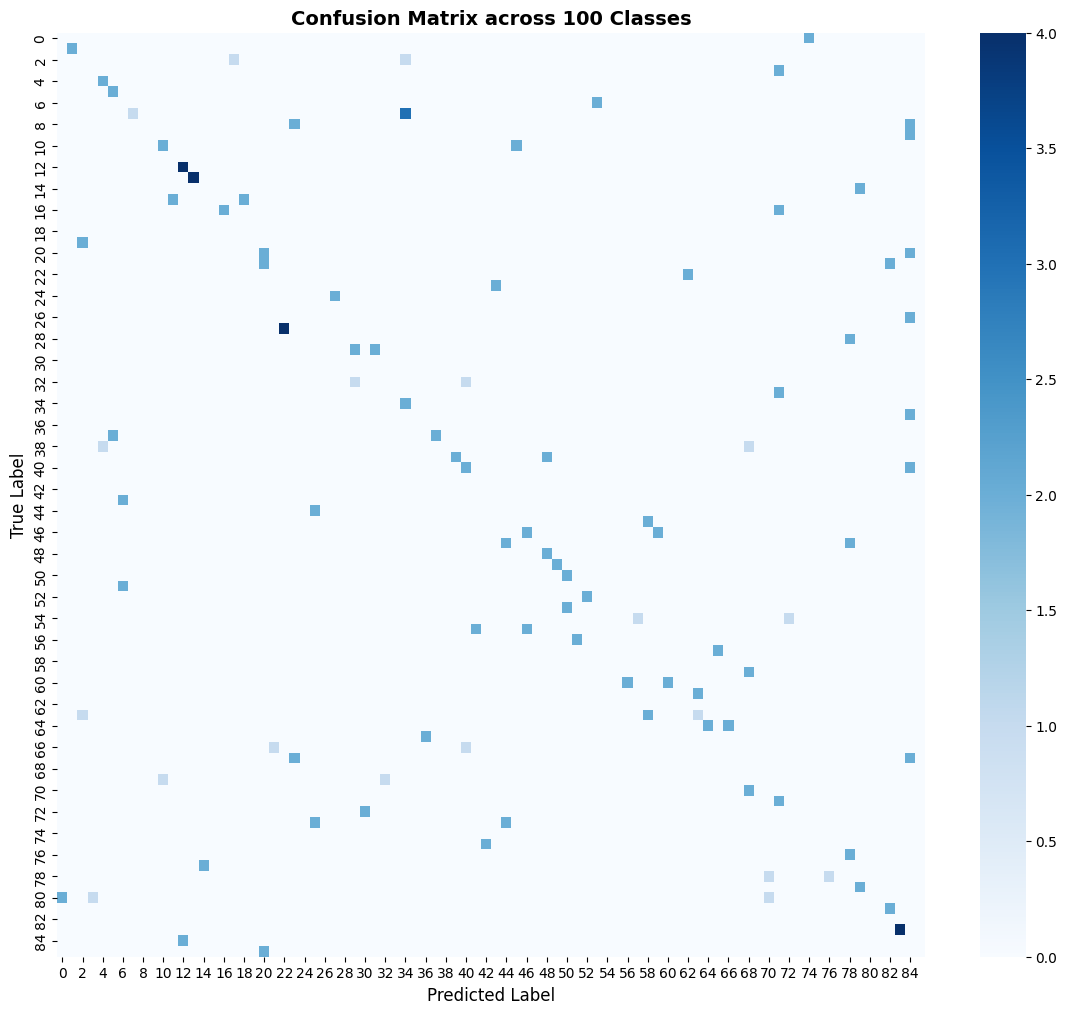

In [ ]:
# --- DETAILED METRICS & CONFUSION MATRIX ---
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Ensure we have all test predictions
model.eval()
test_preds, test_labels = [], []

with torch.no_grad():
  for inputs, labels in test_loader:
    inputs = inputs.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    test_preds.extend(preds.cpu().numpy())
    test_labels.extend(labels.numpy())

# Generate Classification Report
print('📊 CLASSIFICATION REPORT:')
print(
    classification_report(
        test_labels, test_preds, zero_division=0, digits=4
    )
)

# Plot Confusion Matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title('Confusion Matrix across 100 Classes', fontweight='bold', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [ ]:
import glob
import json
import os
import numpy as np

# Paths
DATA_DIR = '/content/drive/MyDrive/SignLanguageProject/augmented_landmarks'
MAPPING_FILE = (
    '/content/drive/MyDrive/SignLanguageProject/class_mapping_100.json'
)

print('=' * 60)
print('🔎 DIAGNOSTIC REPORT: DATA & LABEL MAPPING INSPECTION')
print('=' * 60)

# 1. Inspect class_mapping_100.json
if os.path.exists(MAPPING_FILE):
  with open(MAPPING_FILE, 'r') as f:
    mapping_data = json.load(f)

  print(f'\n1️⃣ CLASS MAPPING FILE (`class_mapping_100.json`):')
  print(f'   - Total keys in JSON: {len(mapping_data)}')
  print(f'   - Data Type of keys: {type(next(iter(mapping_data.keys())))}')
  print(f'   - Data Type of values: {type(next(iter(mapping_data.values())))}')

  # Show first 5 items
  sample_items = list(mapping_data.items())[:5]
  print(f'   - Sample entries (First 5):')
  for k, v in sample_items:
    print(f'     • Key: "{k}" (type {type(k).__name__}) ──> Value: {v}')
else:
  print(f'❌ Mapping file NOT found at: {MAPPING_FILE}')

# 2. Inspect .npy files in DATA_DIR
all_files = glob.glob(os.path.join(DATA_DIR, '*.npy'))
print(f'\n2️⃣ FEATURE FILES (`{DATA_DIR}`):')
print(f'   - Total .npy files found: {len(all_files)}')

if len(all_files) > 0:
  print(f'   - Sample Filenames (First 5):')
  for f in all_files[:5]:
    fname = os.path.basename(f)
    sample_arr = np.load(f)
    print(f'     • File: {fname} | Shape: {sample_arr.shape}')

  # 3. Test matching logic against class_mapping_100.json
  print(f'\n3️⃣ MATCHING TEST (Testing sample filenames against JSON mapping):')
  matched_count = 0
  unmatched_samples = []

  for f in all_files:
    fname = os.path.basename(f).replace('.npy', '')
    base_id = fname.replace('_aug', '')

    # Check direct match, split by underscore, or string match
    if base_id in mapping_data:
      matched_count += 1
    elif fname in mapping_data:
      matched_count += 1
    else:
      if len(unmatched_samples) < 5:
        unmatched_samples.append(fname)

  match_pct = (matched_count / len(all_files)) * 100
  print(
      f'   - Directly matched with JSON keys: {matched_count}/{len(all_files)}'
      f' ({match_pct:.1f}%)'
  )

  if match_pct < 100:
    print(
        f'   - ⚠️ Unmatched sample filenames (First'
        f' {len(unmatched_samples)}): {unmatched_samples}'
    )

print('=' * 60)


🔎 DIAGNOSTIC REPORT: DATA & LABEL MAPPING INSPECTION

1️⃣ CLASS MAPPING FILE (`class_mapping_100.json`):
   - Total keys in JSON: 100
   - Data Type of keys: <class 'str'>
   - Data Type of values: <class 'int'>
   - Sample entries (First 5):
     • Key: "book" (type str) ──> Value: 0
     • Key: "drink" (type str) ──> Value: 1
     • Key: "computer" (type str) ──> Value: 2
     • Key: "before" (type str) ──> Value: 3
     • Key: "chair" (type str) ──> Value: 4

2️⃣ FEATURE FILES (`/content/drive/MyDrive/SignLanguageProject/augmented_landmarks`):
   - Total .npy files found: 1906
   - Sample Filenames (First 5):
     • File: 49181.npy | Shape: (18, 258)
     • File: 49181_aug.npy | Shape: (18, 258)
     • File: 21871.npy | Shape: (40, 258)
     • File: 21871_aug.npy | Shape: (40, 258)
     • File: 57633.npy | Shape: (44, 258)

3️⃣ MATCHING TEST (Testing sample filenames against JSON mapping):
   - Directly matched with JSON keys: 0/1906 (0.0%)
   - ⚠️ Unmatched sample filenames (First 